In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 

In [3]:
from processing import  load_UCI_dataset, train_basic_cnn, plot_loss_vs_epoch, evaluate_cnn_vitaldb

In [4]:
WINDOW_SIZE = 1000     
STEP_SIZE = 500

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_50%overlap/vitaldb_checkpoints"

X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [02:00<00:00, 79.70it/s] 


Skipped recordings: 103


100%|██████████| 1200/1200 [00:15<00:00, 77.10it/s]


Skipped recordings: 8


100%|██████████| 1200/1200 [00:15<00:00, 77.18it/s]


Skipped recordings: 9


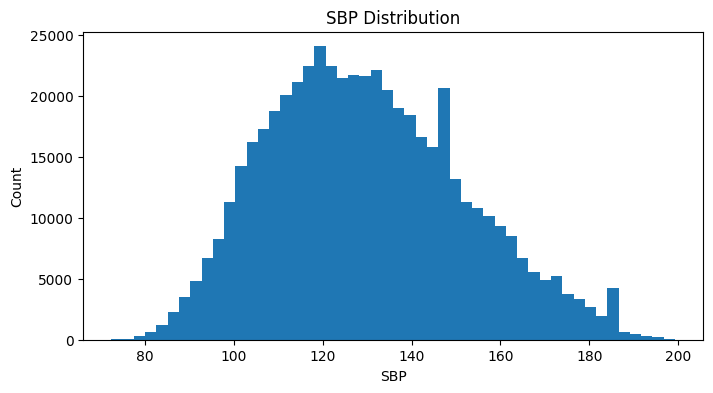

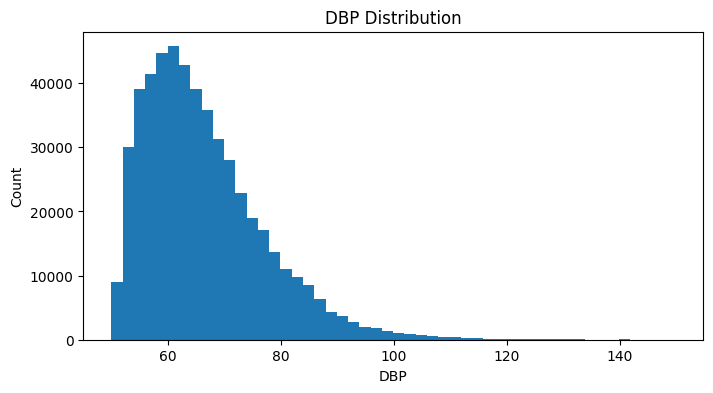

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(y_train[:,0], bins=50)
plt.xlabel("SBP")
plt.ylabel("Count")
plt.title("SBP Distribution")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(y_train[:,1], bins=50)
plt.xlabel("DBP")
plt.ylabel("Count")
plt.title("DBP Distribution")
plt.show()

Train: torch.Size([517037, 1, 1000]) torch.Size([517037, 2])
Val  : torch.Size([65284, 1, 1000]) torch.Size([65284, 2])
Test : torch.Size([65554, 1, 1000]) torch.Size([65554, 2])

Device: cuda
BasicCNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (7): ReLU()
    (8): AdaptiveAvgPool1d(output_size=1)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Epoch 01/100 | Train Loss: 648.1131 | Val Loss: 308.4665 | 

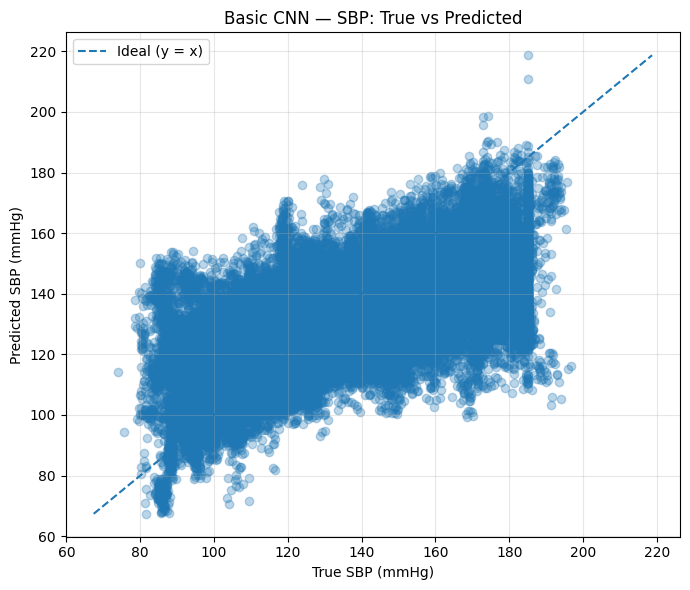

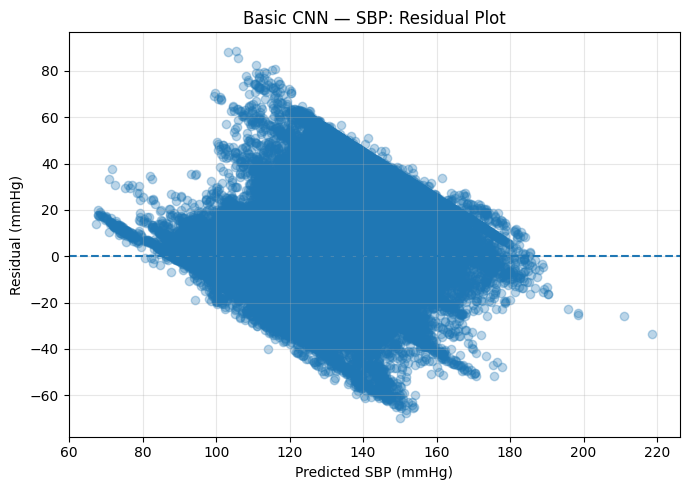

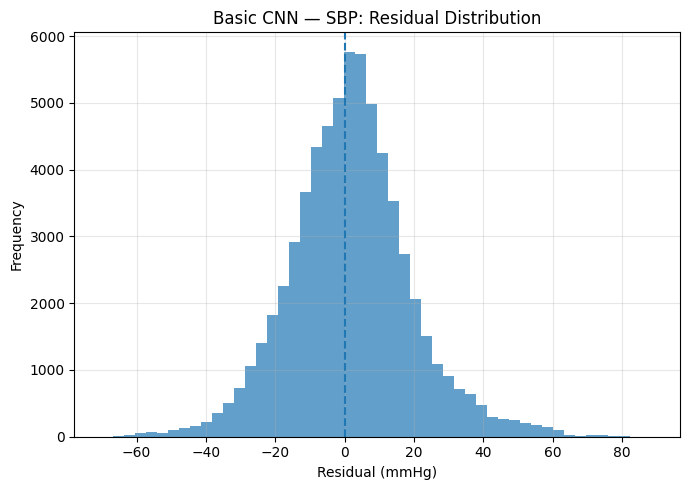

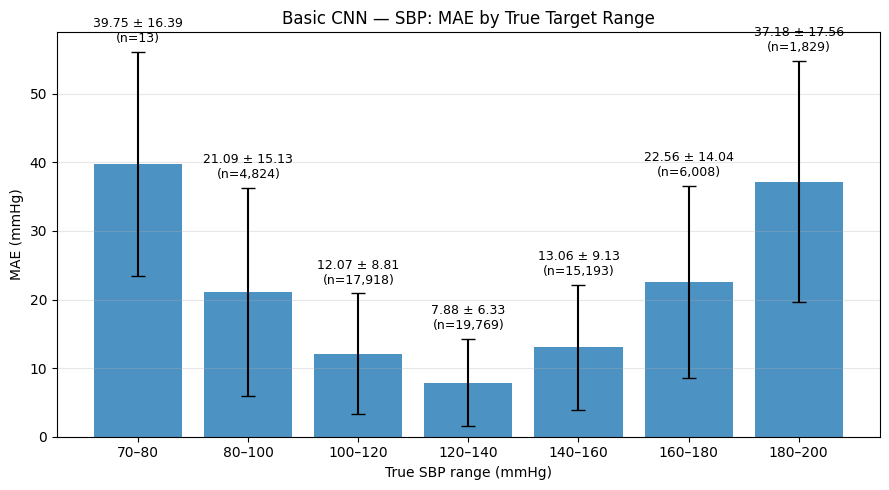

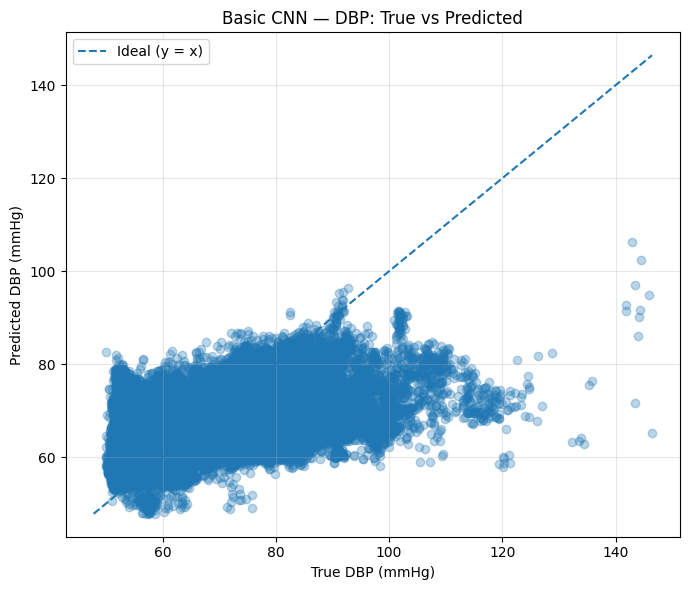

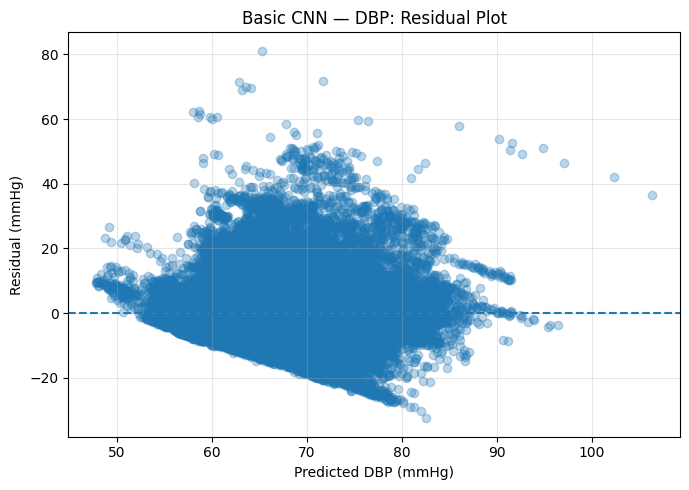

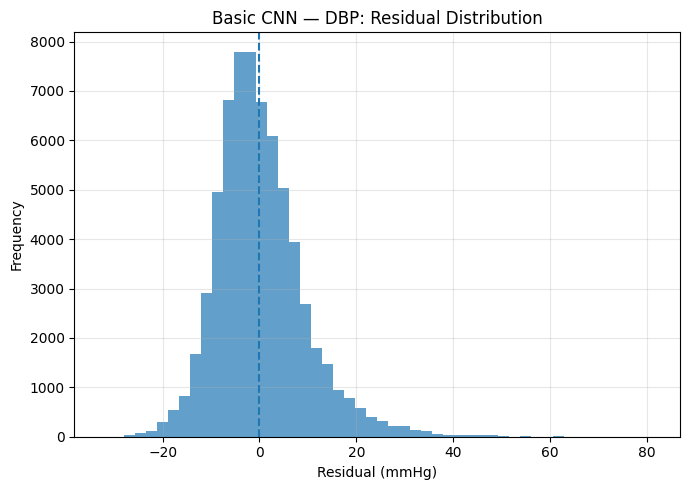

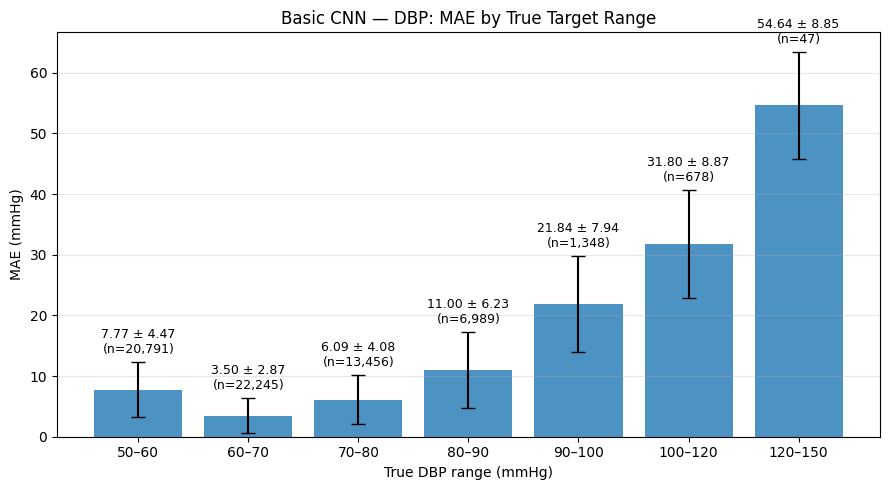

In [6]:
cnn_model, cnn_results = train_basic_cnn(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
)

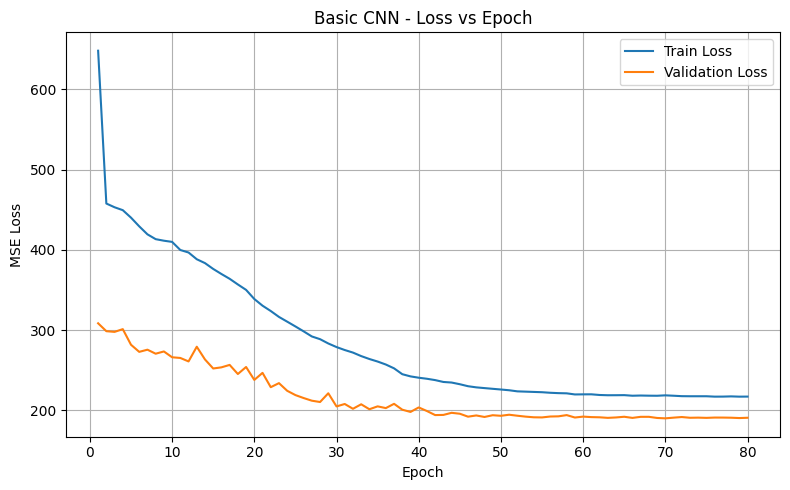

In [7]:
plot_loss_vs_epoch(
    cnn_results["history"],
    model_name="Basic CNN"
)

Number of VitalDB cases: 1962


CNN VitalDB prediction: 100%|██████████| 1962/1962 [03:45<00:00,  8.70case/s]



BASIC CNN
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 33.9962
MSE : 1155.7412
R²  : -1.7094
MAE : 22.1426

DBP
RMSE: 14.6453
MSE : 214.4840
R²  : -0.3259
MAE : 10.9931


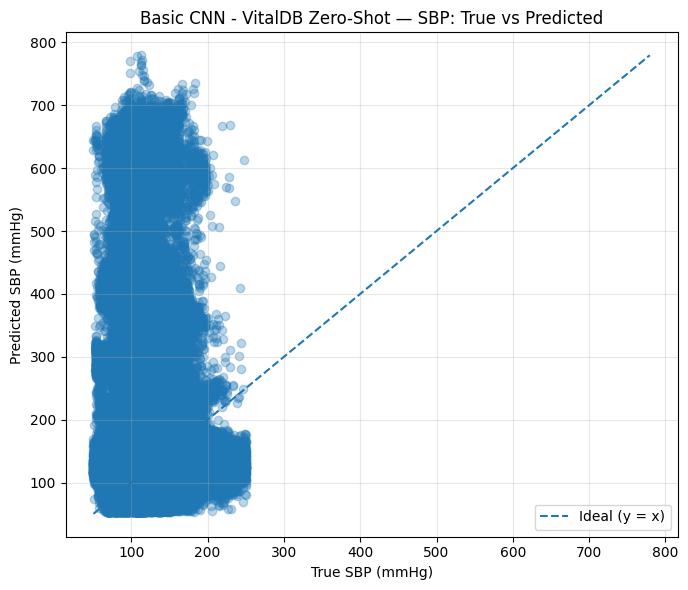

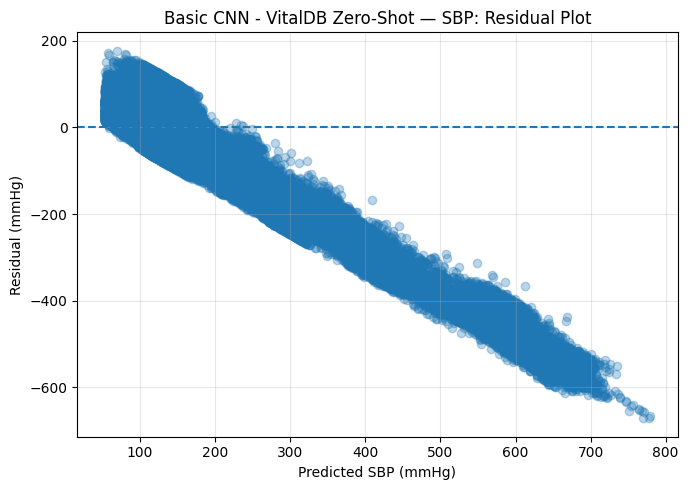

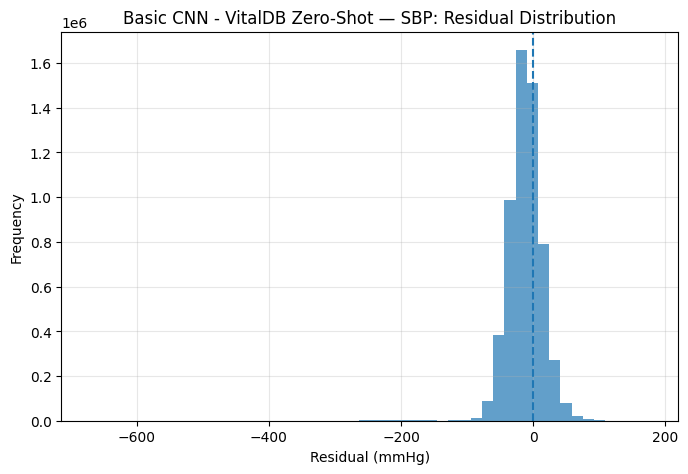

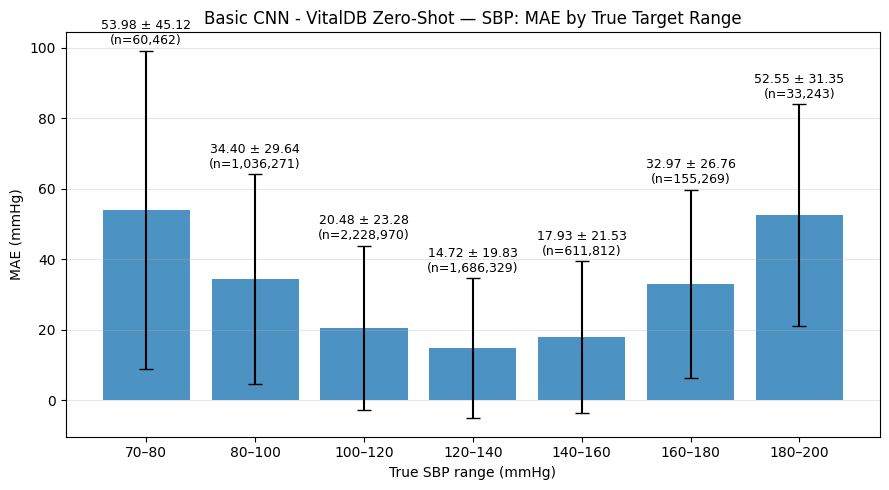

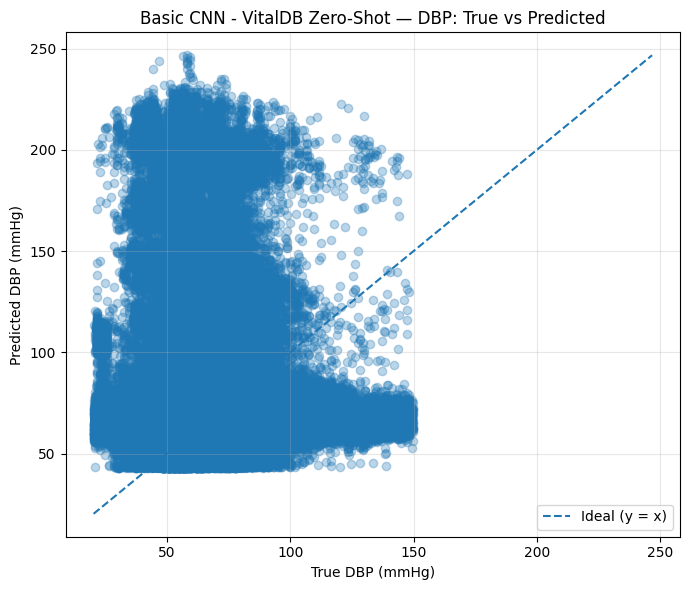

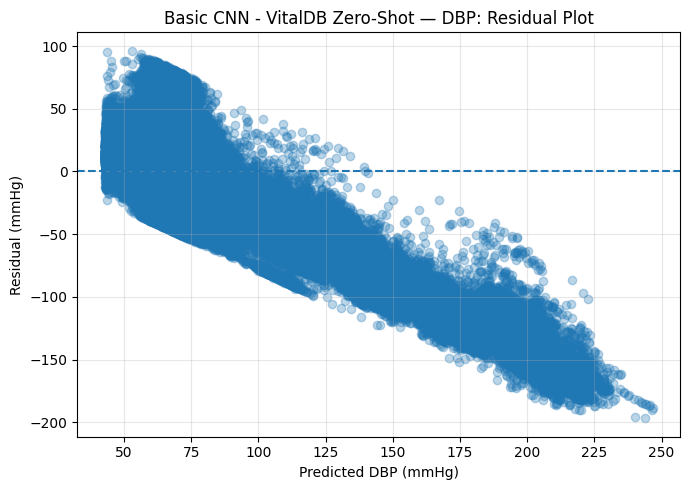

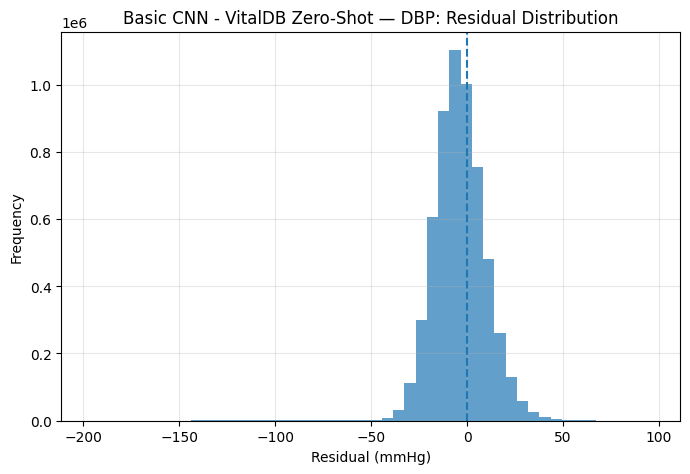

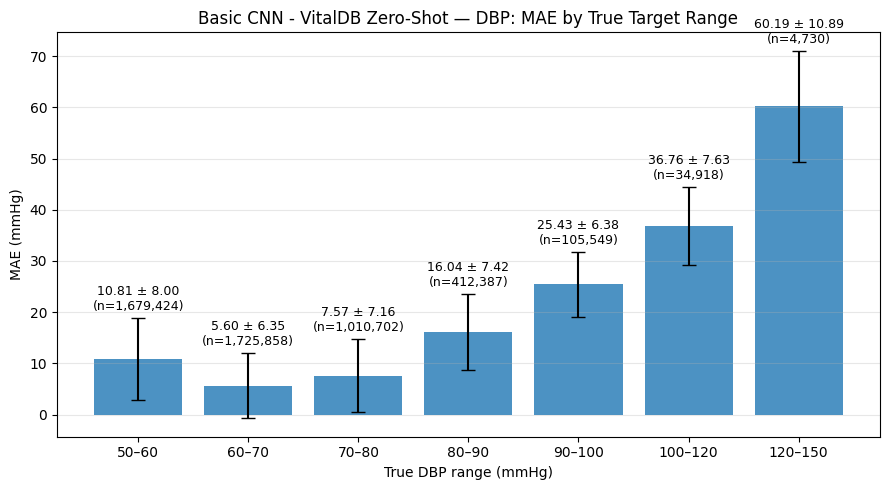

In [8]:
cnn_vitaldb_results = evaluate_cnn_vitaldb(
    model=cnn_model,
    base_dir=BASE_DIR,
    batch_size=256
)